# Responsible Geo-AI - Connecting GeoCroissant and RAI (HLS Burn Scars)

In [1]:
#!pip install mlcroissant

import json
import mlcroissant as mlc
import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
# 1. Define FileObject for the remote ZIP archive
archive = mlc.FileObject(
    id="hls-burn-scars-archive",
    name="hls-burn-scars-archive",
    description="Zip archive containing hls_burn_scars dataset",
    content_url="https://huggingface.co/datasets/harshinde/hls/resolve/main/hls_burn_scars.zip",
    encoding_formats=["application/zip"],
    sha256="dc1ae02e16dd4b7ec99130135a7887305d9e9a664c0ec521e409da207684e8e3",
)

# 2. FileSets define resources inside the archive
distribution = [
    archive,
    mlc.FileSet(
        id="train-images",
        name="train-images",
        description="Training RGB Images",
        contained_in=["hls-burn-scars-archive"],
        encoding_formats=["image/tiff"],
        includes=["train/images/*.tif"],
    ),
    mlc.FileSet(
        id="train-masks",
        name="train-masks",
        description="Training Mask Images",
        contained_in=["hls-burn-scars-archive"],
        encoding_formats=["image/tiff"],
        includes=["train/masks/*.tif"],
    ),
    mlc.FileSet(
        id="valid-images",
        name="valid-images",
        description="Validation RGB Images",
        contained_in=["hls-burn-scars-archive"],
        encoding_formats=["image/tiff"],
        includes=["valid/images/*.tif"],
    ),
    mlc.FileSet(
        id="valid-masks",
        name="valid-masks",
        description="Validation Mask Images",
        contained_in=["hls-burn-scars-archive"],
        encoding_formats=["image/tiff"],
        includes=["valid/masks/*.tif"],
    ),
]

# Helper function to create standard RecordSets
def create_split_record_sets(split_name, image_fileset, mask_fileset):
    return [
        mlc.RecordSet(
            id=f"{split_name}_images",
            name=f"{split_name} images",
            spatial_resolution=mlc.QuantitativeValue(value=30, unitText="m"),
            fields=[
                mlc.Field(
                    id=f"{split_name}/filename",
                    name="filename",
                    data_types=[mlc.DataType.TEXT],
                    source=mlc.Source(
                        file_set=image_fileset,
                        extract=mlc.Extract(file_property="filename"),
                    ),
                ),
                mlc.Field(
                    id=f"{split_name}/image",
                    name="image",
                    data_types=[mlc.DataType.IMAGE_OBJECT],
                    is_array=True,
                    array_shape="512,512,6",
                    band_configuration=mlc.BandConfiguration(
                        total_bands=6,
                        band_names_list=["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
                    ),
                    source=mlc.Source(
                        file_set=image_fileset,
                        extract=mlc.Extract(file_property="content"),
                    ),
                ),
            ],
        ),
        mlc.RecordSet(
            id=f"{split_name}_masks",
            name=f"{split_name} masks",
            fields=[
                mlc.Field(
                    id=f"{split_name}/mask_filename",
                    name="mask_filename",
                    data_types=[mlc.DataType.TEXT],
                    source=mlc.Source(
                        file_set=mask_fileset,
                        extract=mlc.Extract(file_property="filename"),
                    ),
                ),
                mlc.Field(
                    id=f"{split_name}/mask",
                    name="mask",
                    data_types=[mlc.DataType.IMAGE_OBJECT],
                    is_array=True,
                    array_shape="512,512,1",
                    band_configuration=mlc.BandConfiguration(
                        total_bands=1,
                        band_names_list=["mask"]
                    ),
                    source=mlc.Source(
                        file_set=mask_fileset,
                        extract=mlc.Extract(file_property="content"),
                    ),
                ),
            ],
        ),
        mlc.RecordSet(
            id=f"{split_name}_examples",
            name=f"{split_name} examples",
            fields=[
                mlc.Field(
                    id=f"{split_name}_examples/image_key",
                    name="image_key",
                    data_types=[mlc.DataType.TEXT],
                    source=mlc.Source(
                        field=f"{split_name}/filename",
                        transforms=[mlc.Transform(regex=r"^(.+?)(?:_merged\.tif)?$")],
                    ),
                    references=mlc.Source(
                        field=f"{split_name}/mask_filename",
                        transforms=[mlc.Transform(regex=r"^(.+?)(?:\.mask\.tif)?$")],
                    ),
                ),
                mlc.Field(
                    id=f"{split_name}_examples/image",
                    name="image",
                    data_types=[mlc.DataType.IMAGE_OBJECT],
                    is_array=True,
                    array_shape="512,512,6",
                    band_configuration=mlc.BandConfiguration(
                        total_bands=6,
                        band_names_list=["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
                    ),
                    source=mlc.Source(field=f"{split_name}/image"),
                ),
                mlc.Field(
                    id=f"{split_name}_examples/mask",
                    name="mask",
                    data_types=[mlc.DataType.IMAGE_OBJECT],
                    is_array=True,
                    array_shape="512,512,1",
                    band_configuration=mlc.BandConfiguration(
                        total_bands=1,
                        band_names_list=["mask"]
                    ),
                    source=mlc.Source(field=f"{split_name}/mask"),
                ),
            ],
        ),
    ]

record_sets = [
    *create_split_record_sets("train", "train-images", "train-masks"),
    *create_split_record_sets("valid", "valid-images", "valid-masks"),
]

# 3. Create core metadata with GeoCroissant & RAI attributes
metadata = mlc.Metadata(
    name="hls-burn-scars",
    conforms_to=[
        "http://mlcommons.org/croissant/1.1",
        "http://mlcommons.org/croissant/RAI/",
        "http://mlcommons.org/croissant/geo/",
    ],
    description=(
        "Geospatial dataset containing Harmonized Landsat and Sentinel-2 imagery of burn scars "
        "and the associated masks for the years 2018-2021 over the contiguous United States."
    ),
    url="https://huggingface.co/datasets/harshinde/hls/resolve/main/hls_burn_scars.zip",
    cite_as=(
        "@software{HLS_Foundation_2023,\n"
        "    author = {Phillips, Christopher and Roy, Sujit and Ankur, Kumar and Ramachandran, Rahul},\n"
        "    doi    = {10.57967/hf/0956},\n"
        "    month  = aug,\n"
        "    title  = {{HLS Foundation Burnscars Dataset}},\n"
        "    url    = {https://huggingface.co/ibm-nasa-geospatial/hls_burn_scars},\n"
        "    year   = {2023}\n"
        "}"
    ),
    date_published="2023-08-01",
    version="1.0.0",
    license="CC BY-SA 4.0",
    keywords=[
        "hls_burn_scars", "HLS", "burn scars", "fire",
        "remote sensing", "satellite imagery",
        "Landsat", "Sentinel-2", "geospatial",
    ],
    creators=[
        mlc.Person(name="Christopher Phillips"),
        mlc.Person(name="Sujit Roy"),
        mlc.Person(name="Kumar Ankur"),
        mlc.Person(name="Rahul Ramachandran"),
    ],
    # GeoCroissant properties
    coordinate_reference_system="EPSG:32610",
    spatial_resolution=mlc.QuantitativeValue(value=30, unitText="m"),
    temporal_resolution=mlc.QuantitativeValue(value=8, unitText="weeks"),
    sampling_strategy="512x512 windows centered around MTBS burn scar coordinates from HLS tiles.",
    spatial_bias="Concentrated over the contiguous United States (CONUS).",
    
    # RAI properties
    data_collection="Formed by co-locating MTBS shapefiles with HLS imagery, manually filtering for cloud cover.",
    annotator_demographics=["MTBS project team geospatial analysts and forestry specialists"],
    data_biases=["Biased toward CONUS fire events from 2018-2021; scenes are centered on burn scars rather than arbitrary locations."],
    data_limitations=["Manually filtered for cloud-free scenes (idealized dataset); burn scars near tile edges are offset from the center."],
    personal_sensitive_information=["Contains no personal sensitive information; consists solely of public satellite imagery and mask grids."],
    data_use_cases=["Training and validating geospatial machine learning models for semantic segmentation of satellite burn scars."],
    data_social_impact="Enables research into forest fire mapping, recovery tracking, and ecological risk modeling.",
    
    band_configuration=mlc.BandConfiguration(
        total_bands=6,
        band_names_list=["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
    ),
    spectral_band_metadata=[
        mlc.SpectralBand(name="Blue", center_wavelength=mlc.QuantitativeValue(value=490, unitText="nm"), bandwidth=mlc.QuantitativeValue(value=65, unitText="nm")),
        mlc.SpectralBand(name="Green", center_wavelength=mlc.QuantitativeValue(value=560, unitText="nm"), bandwidth=mlc.QuantitativeValue(value=60, unitText="nm")),
        mlc.SpectralBand(name="Red", center_wavelength=mlc.QuantitativeValue(value=665, unitText="nm"), bandwidth=mlc.QuantitativeValue(value=30, unitText="nm")),
        mlc.SpectralBand(name="NIR", center_wavelength=mlc.QuantitativeValue(value=865, unitText="nm"), bandwidth=mlc.QuantitativeValue(value=30, unitText="nm")),
        mlc.SpectralBand(name="SWIR1", center_wavelength=mlc.QuantitativeValue(value=1610, unitText="nm"), bandwidth=mlc.QuantitativeValue(value=90, unitText="nm")),
        mlc.SpectralBand(name="SWIR2", center_wavelength=mlc.QuantitativeValue(value=2200, unitText="nm"), bandwidth=mlc.QuantitativeValue(value=180, unitText="nm")),
    ],
    spatial_coverage={
        "@type": "Place",
        "geo": {
            "@type": "GeoShape",
            "box": "24.396308 -124.848974 49.384358 -66.885444",
        },
    },
    distribution=distribution,
    record_sets=record_sets,
)
print("metadata instantiated")

metadata instantiated


In [3]:
# 4. Serialize to JSON-LD and inject PROV, and ODRL/DUO conditional policies
metadata_json = metadata.to_json()

# Set custom namespaces in the context
metadata_json["@context"]["prov"] = "http://www.w3.org/ns/prov#"
metadata_json["@context"]["odrl"] = "http://www.w3.org/ns/odrl/2/"
# Map duo prefix to OBO base URI to make local parts (DUO_0000042) valid NCName characters (starts with letter)
metadata_json["@context"]["duo"] = "http://purl.obolibrary.org/obo/"
# Map containedIn to cr:containedIn for Croissant 1.1 compatibility
metadata_json["@context"]["containedIn"] = "cr:containedIn"


# W3C PROV-O Provenance
metadata_json["prov:wasDerivedFrom"] = "https://hls.gsfc.nasa.gov/"
metadata_json["prov:wasGeneratedBy"] = {
    "@type": "prov:Activity",
    "name": "HLS Imagery Preprocessing Activity",
    "description": "Re-projecting, subsetting, and normalizing HLS bands.",
    "prov:used": "https://hls.gsfc.nasa.gov/",
    "prov:wasAssociatedWith": {
        "@type": "prov:SoftwareAgent",
        "name": "IBM-NASA Prithvi Preprocessing Pipeline v2.0",
        "description": "Automated band normalization pipeline."
    }
}
metadata_json["prov:wasAttributedTo"] = {
    "@type": "prov:Agent",
    "name": "Monitoring Trends in Burn Severity (MTBS) group",
    "url": "https://mtbs.gov/"
}

# ODRL / DUO Conditional Data Access Policy (Allow general research use)
metadata_json["usageInfo"] = {
    "@type": "odrl:Offer",
    "name": "Usage Policy",
    "odrl:permission": {
        "@type": "odrl:Permission",
        "odrl:action": { "@id": "odrl:use" },
        "odrl:constraint": {
            "@type": "odrl:Constraint",
            "odrl:leftOperand": { "@id": "odrl:purpose" },
            "odrl:operator": { "@id": "odrl:eq" },
            "odrl:rightOperand": { "@id": "duo:DUO_0000042" }
        }
    }
}

# Tag the 'valid masks' RecordSet with synthetic data generation activity
for rs in metadata_json.get("recordSet", []):
    if rs.get("name") == "valid masks":
        rs["rai:hasSyntheticData"] = True
        rs["prov:wasGeneratedBy"] = {
            "@type": "prov:Activity",
            "name": "Validation Mask Synthesis Activity",
            "prov:wasAssociatedWith": {
                "@type": "prov:SoftwareAgent",
                "name": "Prithvi Mask Synthesis Engine",
                "description": "Generates synthetic masks for validation splits."
            }
        }

output_json = "hls_burn_scars.json"
with open(output_json, "w") as f:
    json.dump(metadata_json, f, indent=2)

print(f"metadata saved to {output_json}!")

metadata saved to hls_burn_scars.json!


In [4]:
# validate using mlcroissant
!mlcroissant validate --jsonld=hls_burn_scars.json

I0605 00:26:03.692614 125015533623104 validate.py:53] Done.


In [5]:
# 5. Load using mlcroissant
dataset = mlc.Dataset(jsonld="hls_burn_scars.json")
print("Dataset loaded successfully")

meta = dataset.metadata
print(f"Dataset Name: {meta.name}")
for k, v in meta.extra_properties.items():
    print(f"{k}: {v}")

Dataset loaded successfully
Dataset Name: hls-burn-scars
prov:wasAttributedTo: {'@type': 'prov:Agent', 'name': 'Monitoring Trends in Burn Severity (MTBS) group', 'url': 'https://mtbs.gov/'}
prov:wasDerivedFrom: https://hls.gsfc.nasa.gov/
prov:wasGeneratedBy: {'@type': 'prov:Activity', 'prov:used': 'https://hls.gsfc.nasa.gov/', 'prov:wasAssociatedWith': {'@type': 'prov:SoftwareAgent', 'description': 'Automated band normalization pipeline.', 'name': 'IBM-NASA Prithvi Preprocessing Pipeline v2.0'}, 'description': 'Re-projecting, subsetting, and normalizing HLS bands.', 'name': 'HLS Imagery Preprocessing Activity'}
usageInfo: {'@type': 'odrl:Offer', 'odrl:permission': {'@type': 'odrl:Permission', 'odrl:action': {'@id': 'odrl:use'}, 'odrl:constraint': {'@type': 'odrl:Constraint', 'odrl:leftOperand': {'@id': 'odrl:purpose'}, 'odrl:operator': {'@id': 'odrl:eq'}, 'odrl:rightOperand': {'@id': 'duo:DUO_0000042'}}}, 'name': 'Usage Policy'}


In [6]:
# 6. PyTorch Loader
class HLSDataPipe(IterableDataset):
    def __init__(self, jsonld_path, record_set_id="train_examples"):
        self.dataset = mlc.Dataset(jsonld_path)
        self.record_set_id = record_set_id

    def __iter__(self):
        records = self.dataset.records(self.record_set_id)
        for record in records:
            # Get image and mask readers
            img_obj = record[f"{self.record_set_id}/image"]
            mask_obj = record[f"{self.record_set_id}/mask"]
            
            # Read band array (1-indexed bands for rasterio)
            # Bands: 1=Blue, 2=Green, 3=Red, 4=NIR, 5=SWIR1, 6=SWIR2
            img_data = img_obj.read([1, 2, 3, 4, 5, 6])
            mask_data = np.array(mask_obj)
            
            yield {
                "image_key": record[f"{self.record_set_id}/image_key"],
                "image": torch.tensor(img_data, dtype=torch.float32),
                "mask": torch.tensor(mask_data, dtype=torch.float32)
            }
            
print("PyTorch loader defined!")

PyTorch loader defined!


In [7]:
# 7. Loader and iterate records
datapipe = HLSDataPipe("hls_burn_scars.json", "train_examples")
loader = DataLoader(datapipe, batch_size=1)

print("Iterating over PyTorch DataLoader...")
records_list = []
for i, batch in enumerate(loader):
    print(f"Record {i} loaded:")
    print(f"  Key: {batch['image_key'][0]}")
    print(f"  Image shape: {batch['image'].shape}")
    print(f"  Mask shape: {batch['mask'].shape}")
    
    # Keep records for visualization
    records_list.append(batch)
    if len(records_list) >= 3:
        break

Iterating over PyTorch DataLoader...
Record 0 loaded:
  Key: b'subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4'
  Image shape: torch.Size([1, 6, 512, 512])
  Mask shape: torch.Size([1, 512, 512])
Record 1 loaded:
  Key: b'subsetted_512x512_HLS.S30.T10SEH.2018245.v1.4'
  Image shape: torch.Size([1, 6, 512, 512])
  Mask shape: torch.Size([1, 512, 512])
Record 2 loaded:
  Key: b'subsetted_512x512_HLS.S30.T10SEH.2018280.v1.4'
  Image shape: torch.Size([1, 6, 512, 512])
  Mask shape: torch.Size([1, 512, 512])


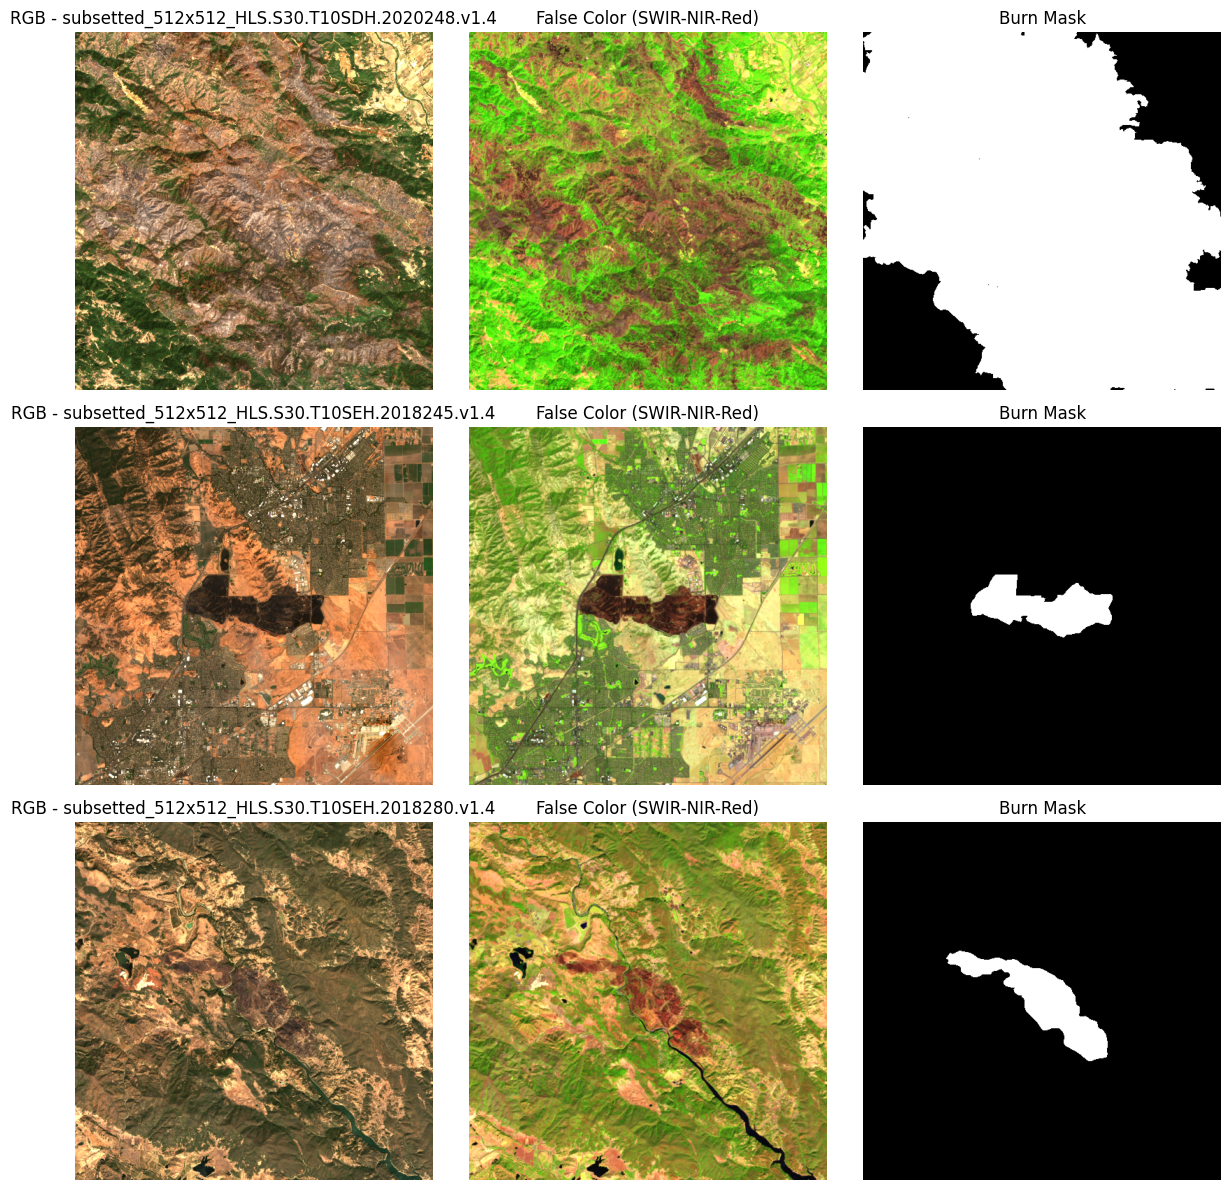

In [8]:
# 8. Visualizing image and mask
fig, axes = plt.subplots(3, 3, figsize=(12, 12), facecolor='white')

for idx, batch in enumerate(records_list):
    # batch['image'] has shape [1, 6, 512, 512] -> remove batch dimension
    img = batch['image'][0].numpy()
    mask = batch['mask'][0].numpy()

    # RGB is bands 3 (Red), 2 (Green), 1 (Blue) -> index 2, 1, 0
    # False Color is bands 5 (SWIR1), 4 (NIR), 3 (Red) -> index 4, 3, 2
    rgb = np.transpose(img[[2, 1, 0], :, :], (1, 2, 0))
    fc = np.transpose(img[[4, 3, 2], :, :], (1, 2, 0))

    # Apply percentile clipping for better visual contrast
    rgb_clipped = np.clip(rgb / np.percentile(rgb, 98), 0, 1)
    fc_clipped = np.clip(fc / np.percentile(fc, 98), 0, 1)

    # Plot RGB
    axes[idx, 0].imshow(rgb_clipped)
    axes[idx, 0].set_title(
        f"RGB - {batch['image_key'][0].decode('utf-8')}",
        color='black'
    )
    axes[idx, 0].axis('off')

    # Plot False Color (SWIR-NIR-Red)
    axes[idx, 1].imshow(fc_clipped)
    axes[idx, 1].set_title(
        "False Color (SWIR-NIR-Red)",
        color='black'
    )
    axes[idx, 1].axis('off')

    # Convert mask to pure black & white
    mask_bw = (mask.squeeze() > 0).astype(np.uint8)

    # Plot Mask
    axes[idx, 2].imshow(mask_bw, cmap='gray', vmin=0, vmax=1)
    axes[idx, 2].set_title("Burn Mask", color='black')
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()